# Model Training & Evaluation

In [29]:
import joblib

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split




Load data

In [30]:
df_matches_with_features = pd.read_csv("model/matches_with_features.csv")

Split features and labels

In [31]:
feature_cols = [
    "total_goals_team1",
    "num_players_with_goals_team1",
    "max_goals_by_single_player_team1",
    "total_matches_team1",
    "matches_with_goals_team1",
    "matches_without_goals_team1",
    "avg_goals_per_match_team1",
    "total_goals_team2",
    "num_players_with_goals_team2",
    "max_goals_by_single_player_team2",
    "total_matches_team2",
    "matches_with_goals_team2",
    "matches_without_goals_team2",
    "avg_goals_per_match_team2",
    "goals_diff",
    "matches_diff",
    "avg_goals_diff",
    "num_players_with_goals_diff",
    "max_goals_diff"
]

X = df_matches_with_features[feature_cols]
y = df_matches_with_features["win"]

Split to training and testing dataset

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Train and evaluate models

In [33]:
models = {
    "logreg": LogisticRegression(max_iter=1000, random_state=42),
    "rf": RandomForestClassifier(n_estimators=200, random_state=42),
    "extratrees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "gb": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "histgb": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

    joblib.dump(model, f"model/{name}/worldcup_model.pkl")
    joblib.dump(feature_cols, f"model/{name}/feature_columns.pkl")
    model_info = {
        "model": name,
        "trained_on": "Worldcup data 2002 - 2022",
        "features": feature_cols
    }

    joblib.dump(model_info, f"model/{name}/model_metadata.pkl")



Evaluation

In [34]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="f1",
    ascending=False
)

,model,accuracy,precision,recall,f1
1,rf,0.675325,0.581818,0.542373,0.561404
2,extratrees,0.655844,0.553571,0.525424,0.539130
0,logreg,0.675325,0.595745,0.474576,0.528302
3,gb,0.636364,0.526316,0.508475,0.517241
4,histgb,0.636364,0.528302,0.474576,0.500000


Visualization of metrics

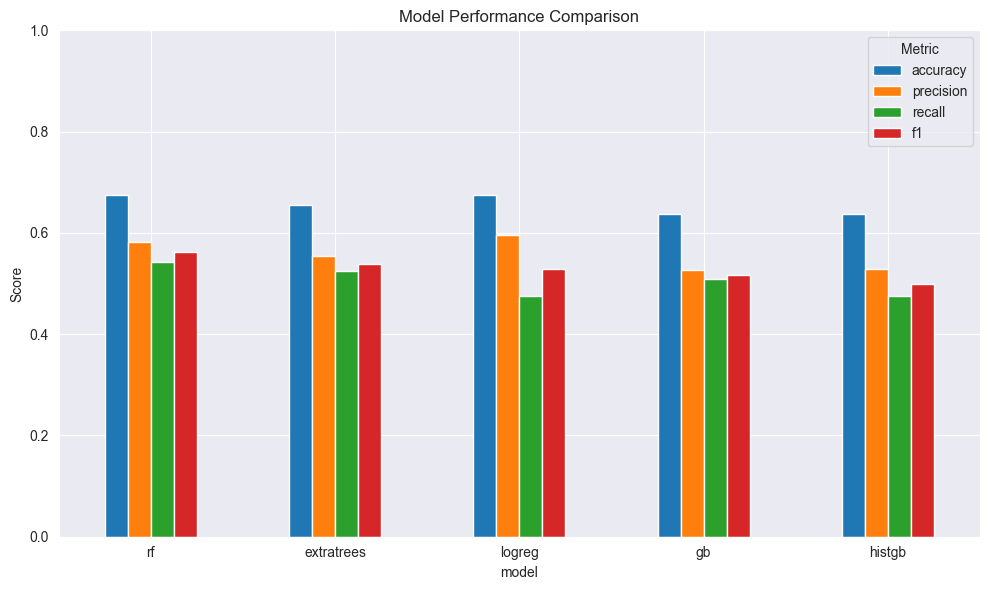

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

metrics = ["accuracy", "precision", "recall", "f1"]

plot_df = results_df.sort_values("f1", ascending=False).set_index("model")[metrics]
ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(title="Metric")

plt.tight_layout()

plt.show()

Feature Importance of Random Forest

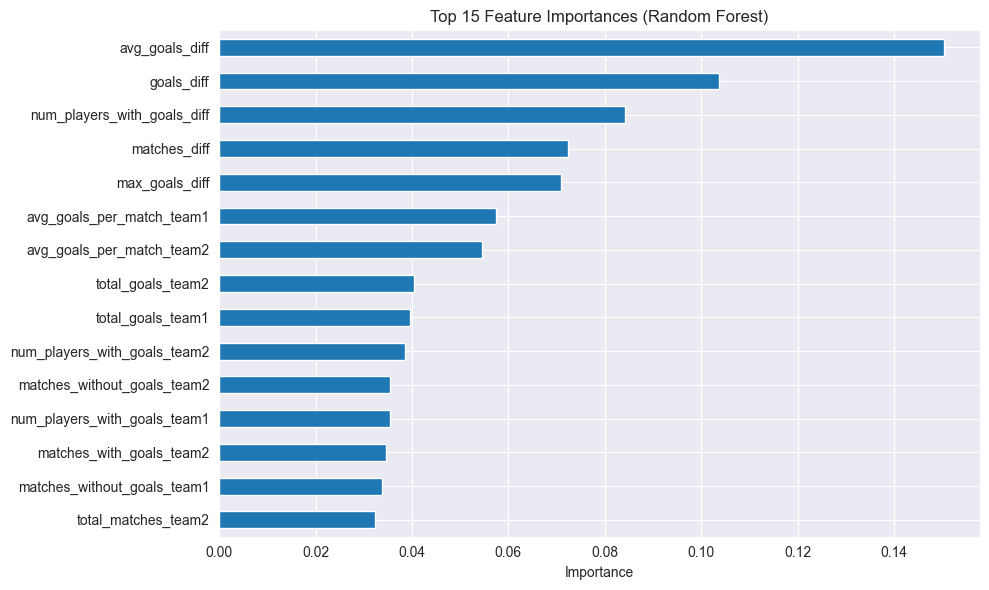

In [36]:
rf_model = models["rf"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

top = importance.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

top.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances (Random Forest)")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()